In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [3]:
data=load_breast_cancer()
X=data.data
Y=data.target
print("dataset shape:",X.shape)
print("classes:",np.unique(Y))

dataset shape: (569, 30)
classes: [0 1]


In [4]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [5]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
mle_model=LogisticRegression(
    penalty=None,
    max_iter=5000,
   random_state=42
)
mle_model.fit(X_train,Y_train)
Y_pred_mle=mle_model.predict(X_test)

In [6]:
map_l2=LogisticRegression(

    penalty='l2',
    C=1.0,
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,Y_train)
Y_pred_l2=map_l2.predict(X_test)

In [7]:
map_l1=LogisticRegression(

    penalty='l1',
    C=1.0,
    solver="liblinear",
    max_iter=5000,
    random_state=42
)
map_l1.fit(X_train,Y_train)
Y_pred_l1=map_l1.predict(X_test)



In [8]:
def evaluvate(model_name,Y_true,Y_pred):
     print("\n","="*40)
     print(model_name)
     print("="*40)
     print("Accuracy:",accuracy_score(Y_true,Y_pred))
     print("precision:",precision_score(Y_true,Y_pred))
     print("Recall:",recall_score(Y_true,Y_pred))
     print("F1 Score:",f1_score(Y_true,Y_pred))
     print("\n Confusion Matrix")
     print(confusion_matrix(Y_true,Y_pred))

In [9]:
evaluvate("MLE",Y_test,Y_pred_mle)
evaluvate("MAP(L2)",Y_test,Y_pred_l2)
evaluvate("MAP(L1)",Y_test,Y_pred_l1)


MLE
Accuracy: 0.9210526315789473
precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Score: 0.935251798561151

 Confusion Matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy: 0.9824561403508771
precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

 Confusion Matrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy: 0.9912280701754386
precision: 0.9863013698630136
Recall: 1.0
F1 Score: 0.993103448275862

 Confusion Matrix
[[41  1]
 [ 0 72]]


In [10]:
print("Number of zero Coefficients")
print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAPL1:",np.sum(map_l1.coef_[0]==0))

Number of zero Coefficients
MLE : 0
MAP L2 : 0
MAPL1: 14


In [11]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])
models=[
    ("MLE",mle_model,Y_pred_mle),
    ("MAP L2",map_l2,Y_pred_l2),
    ("MAP L1",map_l1,Y_pred_l1)
]
for name,model,pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(Y_test,pred),
        precision_score(Y_test,pred),
        recall_score(Y_test,pred),
        f1_score(Y_test,pred)
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


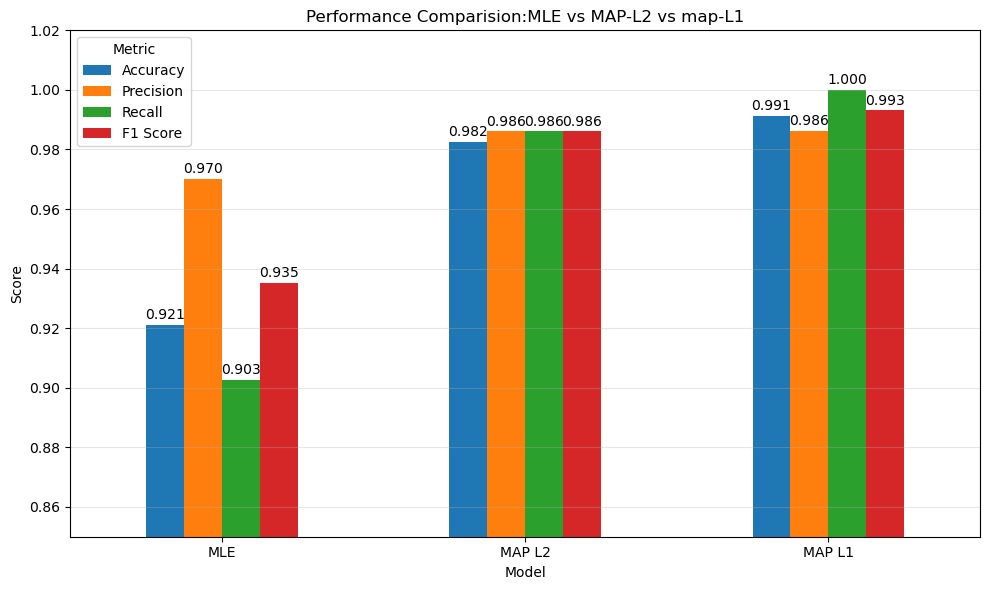

In [12]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparision:MLE vs MAP-L2 vs map-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)

plt.tight_layout()
plt.show()

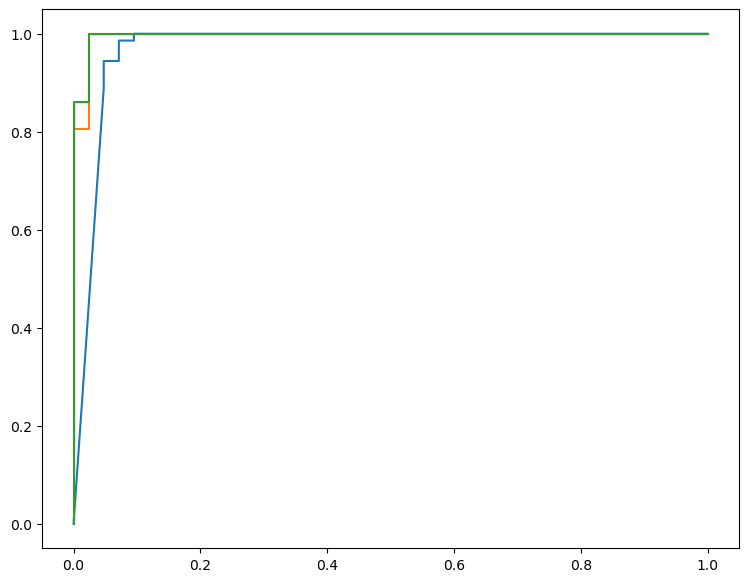

In [13]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    Y_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,thresholds=roc_curve(Y_test,Y_prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(
    fpr,
    tpr,
    label=f"{name}(AUC={roc_auc:.3f})"
    )

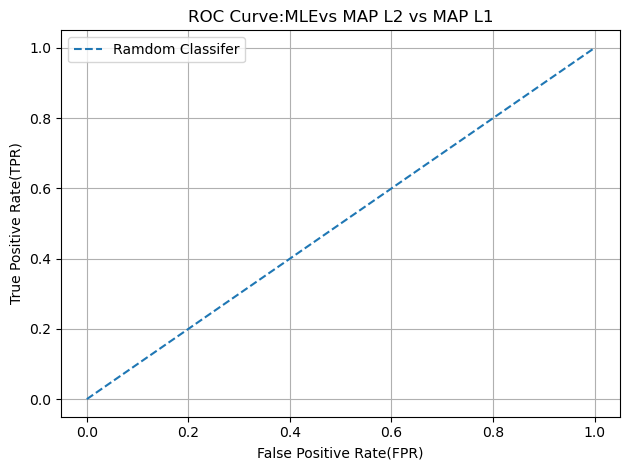

In [17]:
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Ramdom Classifer"
)


plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve:MLEvs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()